In [1]:
import pandas as pd
import sqlite3

con = sqlite3.connect("../data/checking-logs.sqlite")

## Load views per day (users only)

In [2]:
q_views = """
SELECT datetime
FROM pageviews
WHERE uid LIKE 'user_%';
"""
views = pd.io.sql.read_sql(q_views, con, parse_dates=["datetime"])
views["date"] = views["datetime"].dt.date
views_per_day = views.groupby("date").size().rename("views")
views_per_day.head()

date
2020-04-17     1
2020-04-18    23
2020-04-19    15
2020-04-21     3
2020-04-22     1
Name: views, dtype: int64

## Load commits per day (users only)

In [3]:
q_commits = """
SELECT timestamp
FROM checker
WHERE uid LIKE 'user_%';
"""
commits = pd.io.sql.read_sql(q_commits, con, parse_dates=["timestamp"])
commits["date"] = commits["timestamp"].dt.date
commits_per_day = commits.groupby("date").size().rename("commits")
commits_per_day.head()

date
2020-04-17    23
2020-04-18    69
2020-04-19    33
2020-04-20    25
2020-04-21    25
Name: commits, dtype: int64

## Keep only dates where BOTH exist

In [4]:
daily = pd.concat([views_per_day, commits_per_day], axis=1, join="inner")
daily.head()

,views,commits
date,,
2020-04-17,1,23
2020-04-18,23,69
2020-04-19,15,33
2020-04-21,3,25
2020-04-22,1,28


## Plot (match style)

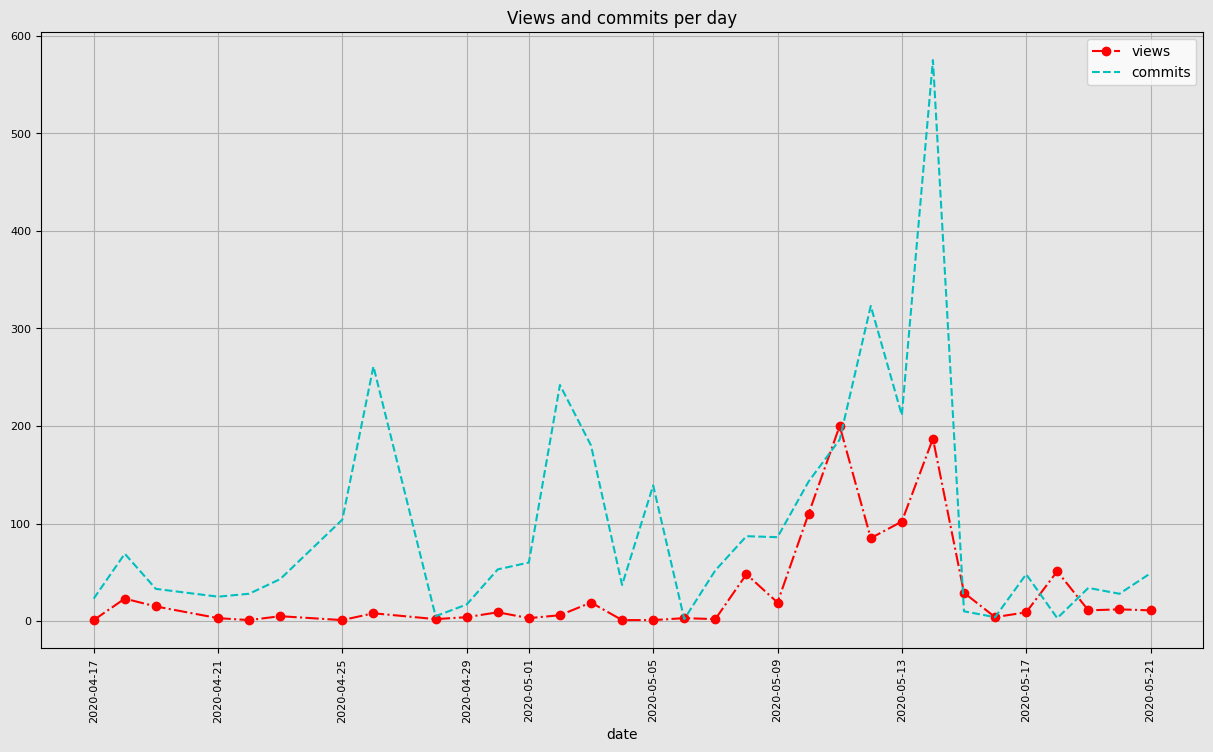

In [5]:
ax = daily.plot(
    figsize=(15, 8),
    fontsize=8,
    title="Views and commits per day",
    style=["r-.o", "c--"]
)

ax.set_xlabel("date")
ax.grid(True)

# background like the sample
ax.set_facecolor("#E6E6E6")
ax.figure.set_facecolor("#E6E6E6")

# rotate x ticks like the sample
ax.tick_params(axis="x", rotation=90)

## Answer 


## How many times was the number of views larger than 150? The answer is ..

In [6]:
answer = int((daily["views"] > 150).sum())
answer

2

In [7]:
con.close()